In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/MyDrive/BootCamp Paper/main coding file/Product Data.csv'

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import matplotlib

In [ ]:
data = pd.read_csv(file_path,encoding='UTF-16',sep='\t')
data.head(10)

,Comment,Sentiment,Stars
0,এই নিয়ে ৩য় বার কিনলাম ! সবকিছু ঠিকঠাক ছিল কি...,0(Negative),3
1,অলিভ অয়েল এককথায় অনেক ভালো। আমার ভালো লাগছে।,1(Positive),5
2,অন্যান্য অনলাইন শপিং প্ল্যাটফর্মের তুলনায় অতি...,0(Negative),3
3,খুব ভালো তাড়াতাড়ি পেয়েছি ধন্যবাদ,1(Positive),5
4,খুবই ভালো পন্য। অরিজিনাল পন্য। ভাউচার সহ ২৪৫ ট...,1(Positive),5
5,ভালো না।নকল।আমি ফেরত দিবো। আসলটার উপরে একটা স্...,0(Negative),2
6,"আলহামদুলিল্লাহ্ ঠিক ভাবে পাইছি,অনেক অনেক অনেক ...",1(Positive),5
7,পন্য দেখে মনে হলো দুই নাম্বার। কেরানীগঞ্জে বান...,0(Negative),2
8,তেমন ভালো না গন্ধ বাজে,0(Negative),2
9,সময়মতো পেয়েছি ।ভালো প্রোডাক্ট। সবাই ব্যবহার ...,1(Positive),5


In [ ]:
print("Total Reviews:",len(data),
      "\nTotal Positive Reviews:",len(data[data.Sentiment =='1(Positive)']),
      "\nTotal Negative Reviews:",len(data[data.Sentiment=='0(Negative)']))

Total Reviews: 300 
Total Positive Reviews: 150 
Total Negative Reviews: 150


In [ ]:
data.columns

Index(['Comment', 'Sentiment', 'Stars'], dtype='object')

In [ ]:
# print some unprocessed reviews
sample_data = [10,100,150,200,250]
for i in sample_data:
      print(data.Comment[i],'\n','Sentiment:-- ',data.Sentiment[i],'\n')

ধন্যবাদ সঠিক পণ্য দেয়ার জন্য 
 Sentiment:--  1(Positive) 

চেয়েছিলাম কালো রঙের আর দিছেন মিকি মাউস ।একদমই আশা করিনি এমন 
 Sentiment:--  0(Negative) 

একেবারে খাঁটি জিনিস। আমি QR কোড চেক করে দেখলাম আসল তেল থাইল্যান্ডের তৈরি। 
 Sentiment:--  1(Positive) 

ব্যবহার করে দেখেছি খুব ভালো লেগেছে | সত্যিই দোকানের বিক্রিতাকে বিশ্বাস করা যায় যেকোনো পণ্য কেনার ক্ষেত্রে 
 Sentiment:--  1(Positive) 

এরা প্যাকেট খোলা পণ্য দেয় তখনই আমার সন্দেহ হয়েছিল পরে দেখি সুইচ নষ্ট। আমি কখনো আর দারাজ থেকে কিছু কিনবো না ।আমাকে এরা পণ্য ফেরতও দেয়নি। 
 Sentiment:--  0(Negative) 



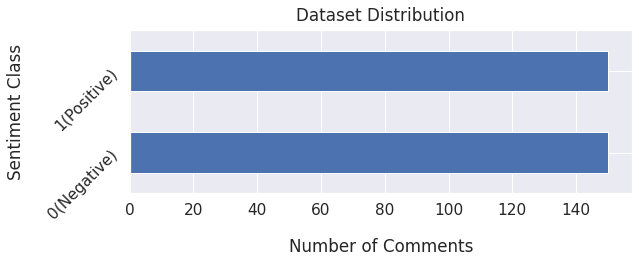

In [ ]:
sns.set(font_scale=1.4)
data['Sentiment'].value_counts().plot(kind='barh', figsize=(9, 3))
plt.xlabel("Number of Comments", labelpad=20)
plt.ylabel("Sentiment Class", labelpad=20)
plt.yticks(rotation = 45)
plt.title("Dataset Distribution", y=1.02);

# Data Cleaning

labelpad : scalar, optional, default: None. Spacing in points from the axes bounding box including ticks and tick labels

In [ ]:
# Data cleaning function
import re
def process_comments(Comment):
    Comment = re.sub('[^\u0980-\u09FF]',' ',str(Comment)) #removing unnecessary punctuation
    return Comment

In [ ]:
# Apply the function into the dataframe
data['cleaned'] = data['Comment'].apply(process_comments)

# print some cleaned reviews from the dataset
sample_data = [10,100,25,250,27,155]
for i in sample_data:
     print('Original:\n',data.Comment[i],'\nCleaned:\n',
           data.cleaned[i],'\n','Sentiment:-- ',data.Sentiment[i],'\n')

Original:
 ধন্যবাদ সঠিক পণ্য দেয়ার জন্য 
Cleaned:
 ধন্যবাদ সঠিক পণ্য দেয়ার জন্য 
 Sentiment:--  1(Positive) 

Original:
 চেয়েছিলাম কালো রঙের আর দিছেন মিকি মাউস ।একদমই আশা করিনি এমন 
Cleaned:
 চেয়েছিলাম কালো রঙের আর দিছেন মিকি মাউস  একদমই আশা করিনি এমন 
 Sentiment:--  0(Negative) 

Original:
 ব্রণের জন্য দারুন একটা জিনিস গত এক বছর ধরে ব্যবহার করতেছি বেশ ভালো কাজ করে  
Cleaned:
 ব্রণের জন্য দারুন একটা জিনিস গত এক বছর ধরে ব্যবহার করতেছি বেশ ভালো কাজ করে  
 Sentiment:--  1(Positive) 

Original:
 এরা প্যাকেট খোলা পণ্য দেয় তখনই আমার সন্দেহ হয়েছিল পরে দেখি সুইচ নষ্ট। আমি কখনো আর দারাজ থেকে কিছু কিনবো না ।আমাকে এরা পণ্য ফেরতও দেয়নি। 
Cleaned:
 এরা প্যাকেট খোলা পণ্য দেয় তখনই আমার সন্দেহ হয়েছিল পরে দেখি সুইচ নষ্ট  আমি কখনো আর দারাজ থেকে কিছু কিনবো না  আমাকে এরা পণ্য ফেরতও দেয়নি  
 Sentiment:--  0(Negative) 

Original:
 পণ্যটি ব্যাবহার করলে আমার মুখ কালো হয়ে যায় আর মুখে ব্রণ দিয়ে ভরে যায় ।মুখের অবস্থা এমন হয় যেন পুড়ে গেছে ।মনে হচ্ছে টাকা নষ্ট করেছি। 
Cleaned:
 পণ্যটি ব্যাবহার করলে

# Dataset Summary

In [ ]:
def data_summary(data):

    reviews = []
    words = []
    u_words = []
    total_u_words = [word.strip().lower() for t in list(data.cleaned) for word in t.strip().split()]
    class_label= [k for k,v in data.Sentiment.value_counts().to_dict().items()]
  # find word list
    for label in class_label:
        word_list = [word.strip().lower() for t in list(data[data.Sentiment==label].cleaned) for word in t.strip().split()]
        counts = dict()
        for word in word_list:
                counts[word] = counts.get(word, 0)+1
        # sort the dictionary of word list
        ordered = sorted(counts.items(), key= lambda item: item[1],reverse = True)
        # reviewss per class
        reviews.append(len(list(data[data.Sentiment==label].cleaned)))
        # Total Word per class
        words.append(len(word_list))
        # Unique words per class
        u_words.append(len(np.unique(word_list)))

        print("\nClass Name : ",label)
        print("Number of Reviews:{}".format(len(list(data[data.Sentiment==label].cleaned))))
        print("Number of Words:{}".format(len(word_list)))
        print("Number of Unique Words:{}".format(len(np.unique(word_list))))
        print("Most Frequent Words:\n")
        for k,v in ordered[:10]:
              print("{}\t{}".format(k,v))
    print("Total Number of Unique Words:{}".format(len(np.unique(total_u_words))))

    return reviews,words,u_words,class_label

#call the fucntion
reviews,words,u_words,class_names = data_summary(data)


Class Name :  0(Negative)
Number of Reviews:150
Number of Words:2050
Number of Unique Words:817
Most Frequent Words:

না	78
পণ্য	54
আমি	34
ভালো	29
বাজে	27
খুবই	22
আর	21
খুব	20
খারাপ	20
ছিল	19

Class Name :  1(Positive)
Number of Reviews:150
Number of Words:2058
Number of Unique Words:617
Most Frequent Words:

ভালো	104
পণ্য	87
ধন্যবাদ	66
অনেক	60
খুব	55
আমি	37
এবং	34
পারেন	31
সুন্দর	31
ভাল	31
Total Number of Unique Words:1185


# Dataset Summary Visualization

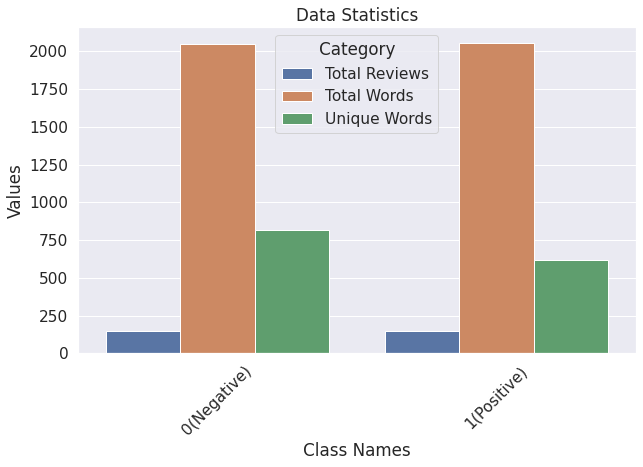

In [ ]:
data_matrix = pd.DataFrame({'Total Reviews':reviews,
                            'Total Words':words,
                            'Unique Words':u_words,
                            'Class Names':class_names})
df = pd.melt(data_matrix, id_vars="Class Names", var_name="Category", value_name="Values")
plt.figure(figsize=(10, 6))
ax = plt.subplot()

sns.barplot(data=df,x='Class Names', y='Values' ,hue='Category')
ax.set_xlabel('Class Names')
ax.set_title('Data Statistics')

ax.xaxis.set_ticklabels(class_names, rotation=45);

# Comment Lenght Distribution

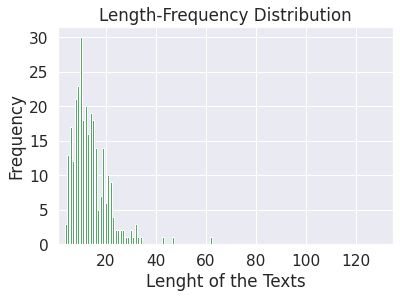

Maximum Length of a review: 62
Minimum Length of a review: 4
Average Length of a reviews: 14.0


In [ ]:
# Calculate the Review of each of the Review
data['ReviewLength'] = data.cleaned.apply(lambda x:len(x.split()))
frequency = dict()
for i in data.ReviewLength:
    frequency[i] = frequency.get(i, 0)+1

plt.bar(frequency.keys(), frequency.values(), color ="g")
plt.xlim(1, 135)

plt.xlabel('Lenght of the Texts')
plt.ylabel('Frequency')
plt.title('Length-Frequency Distribution')
plt.show()
print(f"Maximum Length of a review: {max(data.ReviewLength)}")
print(f"Minimum Length of a review: {min(data.ReviewLength)}")
print(f"Average Length of a reviews: {round(np.mean(data.ReviewLength),0)}")

# Lable Encoding and Dataset Splitting

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score,f1_score
from tensorflow.keras.preprocessing.text import Tokenizer

In [ ]:
def label_encoding(sentiment,bool):

    le = LabelEncoder()
    le.fit(sentiment)
    encoded_labels = le.transform(sentiment)
    labels = np.array(encoded_labels) # Converting into numpy array
    class_names =le.classes_ ## Define the class names again
    if bool == True:
        print("\n\t\t\t===== Label Encoding =====","\nClass Names:-->",le.classes_)
        for i in sample_data:
            print(sentiment[i],' ', encoded_labels[i],'\n')

    return labels

In [ ]:
#===========================================================
                           ################# Dataset Splitting Function ###############
                           #===========================================================

def dataset_split(feature_space,sentiment):
    """
    This function will return the splitted (80%-20%) feature vector .

    Args:
        feature_space: calcuated feature vector (sparse matrix)
        sentiment: encoded lables (array)

    Returns:
        X_train: training feature vector (sparse matrix)
        X_test : testing feature vector (sparse matrix)
        y_train: training encoded labels (array)
        y_test : testing encoded labels (array)
    """

    X_train,X_test,y_train,y_test = train_test_split(feature_space,sentiment,train_size = 0.9,
                                                  test_size = 0.1,random_state =0)
    print("Feature Size :======>",X_train.shape[1])
    print("\nDataset Distribution:\n")
    print("\tSet Name","\t\tSize")
    print("\t========\t\t======")

    print("\tFull\t\t\t",feature_space.shape[0],
        "\n\tTraining\t\t",X_train.shape[0],
        "\n\tTest\t\t\t",X_test.shape[0])

    return X_train,X_test,y_train,y_test

In [ ]:
data.cleaned = data.cleaned.apply(lambda x:x.replace('\n',' '))

# Model Building Using Machine Learning Feature Extraction Using TF-IDF

In [ ]:
def calc_gram_tfidf(reviews,gram):
    tfidf = TfidfVectorizer(ngram_range=gram,use_idf=True,tokenizer=lambda x: x.split())
    X = tfidf.fit_transform(reviews)

    return tfidf,X

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import average_precision_score,roc_auc_score, roc_curve, precision_recall_curve

In [ ]:
def ml_models_defination():
    lr_model = LogisticRegression(random_state = 123)
    dt_model = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
    rf_model = RandomForestClassifier(n_estimators=100, criterion ='entropy', random_state = 0)
    mnb_model = MultinomialNB(alpha=0.15)
    knn_model = KNeighborsClassifier(n_neighbors=3, metric = 'minkowski')
    lsvm_model = SVC(kernel = 'linear',C = 0.2, probability=True, random_state = 0)
    ksvm_model = SVC(C= 1000,kernel = 'rbf',probability=True, gamma = 0.00015, random_state = 0)
    model_names = ['Logistic Regression','Decision Tree','Random Forest','Naive Bayes','KNN','Linear SVM','Kernel SVM']
    ml_models = [lr_model,dt_model,rf_model,mnb_model,knn_model,lsvm_model,ksvm_model]

    return ml_models,model_names

In [ ]:
def model_performace(model,X_train,X_test,y_train,y_test):
    my_dict = {}
    model.fit(X_train,y_train)
    # Prediction
    pred_y = model.predict(X_test)
    my_dict['Accuracy'] = round(accuracy_score(y_test, pred_y),4)*100
    my_dict['Precision'] = round(precision_score(y_test, pred_y),4)*100
    my_dict['Recall'] = round(recall_score(y_test, pred_y),4)*100
    my_dict['F1 Score'] = round(f1_score(y_test, pred_y),4)*100

    return my_dict

In [ ]:
def performance_table(performance_dict):
    acc_list = []
    pr_list = []
    re_list = []
    f1_list = []
    for i in performance_dict.keys():
        acc_list.append(performance_dict[i]['Accuracy'])
        pr_list.append(performance_dict[i]['Precision'])
        re_list.append(performance_dict[i]['Recall'])
        f1_list.append(performance_dict[i]['F1 Score'])


    model_names = ['Logistic Regression','Decision Tree','Random Forest','Multi. Naive Bayes','KNN','Linear SVM','RBF SVM']
    performance_df = pd.DataFrame({'Accuracy':acc_list,'Precision':pr_list,
                                   'Recall':re_list,'F1 Score':f1_list,
                                   'Model Name':model_names })
    return performance_df

# Model Training

In [ ]:
import json
path ='/content/drive/MyDrive/BootCamp Paper/Product Data a.csv'

In [ ]:
## save the performance of the model for each gram feature
gram_names = ['Unigram','Bigram','Trigram']
ngrams = [(1,1),(1,2),(1,3)]
for i,gram in enumerate(ngrams):
    tfidf,feature = calc_gram_tfidf(data.cleaned,gram)
    labels = label_encoding(data.Sentiment,False)
    X_train,X_test,y_train,y_test = dataset_split(feature,labels)
    ml_models,model_names = ml_models_defination()

    accuracy = {f'{model_names[j]}':model_performace(model,X_train,X_test,y_train,y_test) for j,model in enumerate(ml_models)}

    with open(path+f'ml_performance_{gram_names[i]}.json', 'w') as f:
           json.dump(accuracy, f)

Feature Size :======> 1185

Dataset Distribution:

	Set Name 		Size
	========		======
	Full			 300 
	Training		 270 
	Test			 30
Feature Size :======> 4213

Dataset Distribution:

	Set Name 		Size
	========		======
	Full			 300 
	Training		 270 
	Test			 30
Feature Size :======> 7572

Dataset Distribution:

	Set Name 		Size
	========		======
	Full			 300 
	Training		 270 
	Test			 30


In [ ]:
gram_names = ['Unigram','Bigram','Trigram']

for gram in gram_names:
  accuracy = json.load(open(path+f'ml_performance_{gram}.json'))
  table = performance_table(accuracy)
  print(f"\n========== Performace Table for {gram} feature:========\n",table)
  print(f"\n========In case of {gram} feature:========\n")
  print(f"Highest Accuracy achieved by {table['Model Name'][table.Accuracy.idxmax(axis = 0)]} at = {max(table.Accuracy)}")
  print(f"Highest F1-Score achieved by {table['Model Name'][table['F1 Score'].idxmax(axis = 0)]} at = {max(table['F1 Score'] )}")
  print(f"Highest Precision Score achieved by {table['Model Name'][table['Precision'].idxmax(axis = 0)]} at = {max(table['Precision'] )}")
  print(f"Highest Recall Score achieved by {table['Model Name'][table['Recall'].idxmax(axis = 0)]} at = {max(table['Recall'] )}")


========== Performace Table for Unigram feature:========
    Accuracy  Precision  Recall  F1 Score           Model Name
0     96.67     100.00   92.31     96.00  Logistic Regression
1     93.33      92.31   92.31     92.31        Decision Tree
2     96.67     100.00   92.31     96.00        Random Forest
3    100.00     100.00  100.00    100.00   Multi. Naive Bayes
4     90.00      85.71   92.31     88.89                  KNN
5     90.00     100.00   76.92     86.96           Linear SVM
6     90.00     100.00   76.92     86.96              RBF SVM

========In case of Unigram feature:========

Highest Accuracy achieved by Multi. Naive Bayes at = 100.0
Highest F1-Score achieved by Multi. Naive Bayes at = 100.0
Highest Precision Score achieved by Logistic Regression at = 100.0
Highest Recall Score achieved by Multi. Naive Bayes at = 100.0

========== Performace Table for Bigram feature:========
    Accuracy  Precision  Recall  F1 Score           Model Name
0     96.67     100.00   92.31 

# Performance Visualization

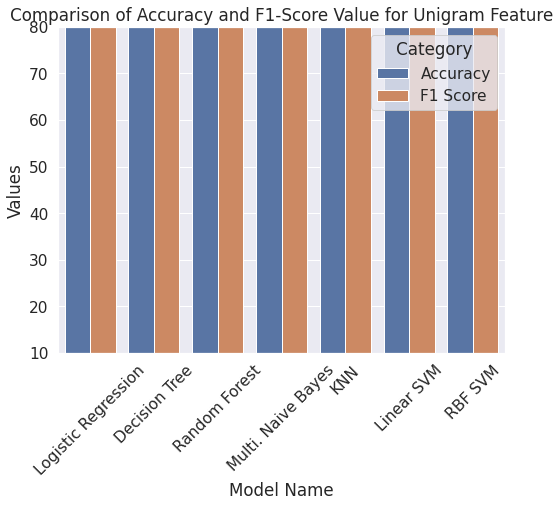

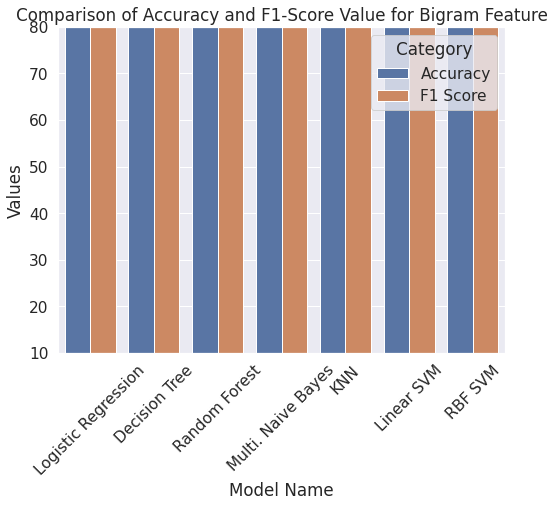

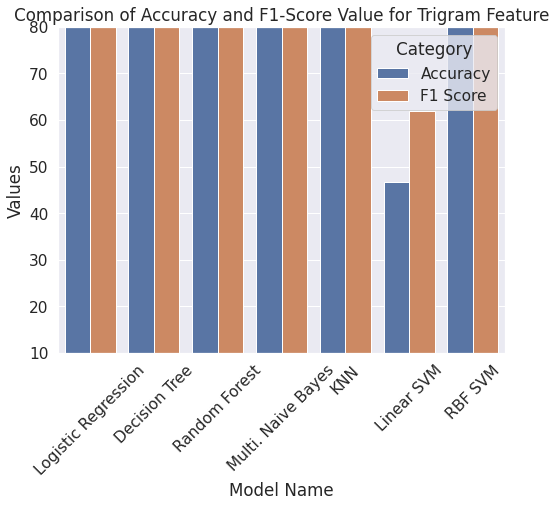

In [ ]:
gram_names = ['Unigram','Bigram','Trigram']

for gram in gram_names:
  accuracy = json.load(open(path+f'ml_performance_{gram}.json'))
  table = performance_table(accuracy)
  df = pd.melt(table[['Accuracy','F1 Score','Model Name']], id_vars="Model Name", var_name="Category", value_name="Values")
  plt.figure(figsize=(8,6))
  ax = plt.subplot()
  sns.barplot(data=df,x='Model Name', y='Values' ,hue='Category')
  ax.set_xlabel('Model Name')
  ax.set_title(f'Comparison of Accuracy and F1-Score Value for {gram} Feature')
  ax.set_ylim([10,80])
  ax.xaxis.set_ticklabels(table['Model Name'], rotation=45);

**Table for Accuracy along with Precision, Recall and F1_Score**

In [ ]:
table = performance_table(accuracy)
df3 =pd.DataFrame(table)
table

,Accuracy,Precision,Recall,F1 Score,Model Name
0,96.67,100.00,92.31,96.00,Logistic Regression
1,86.67,90.91,76.92,83.33,Decision Tree
2,96.67,100.00,92.31,96.00,Random Forest
3,100.00,100.00,100.00,100.00,Multi. Naive Bayes
4,86.67,84.62,84.62,84.62,KNN
5,46.67,44.83,100.00,61.90,Linear SVM
6,100.00,100.00,100.00,100.00,RBF SVM


In [ ]:
print(f"Highest Accuracy achieved by {table.Accuracy.idxmax(axis = 0)} at = {max(table.Accuracy)}")
print(f"Highest F1-Score achieved by {table['F1 Score'].idxmax(axis = 0)} at = {max(table['F1 Score'] )}")
print(f"Highest Precision Score achieved by {table['Precision'].idxmax(axis = 0)} at = {max(table['Precision'] )}")
print(f"Highest Recall Score achieved by {table['Recall'].idxmax(axis = 0)} at = {max(table['Recall'] )}")

Highest Accuracy achieved by 3 at = 100.0
Highest F1-Score achieved by 3 at = 100.0
Highest Precision Score achieved by 0 at = 100.0
Highest Recall Score achieved by 3 at = 100.0


**Select best classifier model**

In [ ]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
dt_model.score(X_test,y_test)

0.8666666666666667

**Confusion matrix**

In [ ]:
y_test

array([0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 1])